# 6CS012 - Worksheet 4
# Building a Fully Connected Network (FCN) for Devnagari Digit Classification

### Name: Aabhash Acharya
### ID: 2418126

---
## Imports

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2


---
## Task 1: Data Preparation

We load the Devnagari digit images from the dataset directory using PIL, resize them to 28x28 grayscale, normalize pixel values to [0, 1], and one-hot encode the labels.

In [3]:
# -------------------------------------------------------
# Task 1: Load and Preprocess the Devnagari Digit Dataset
# -------------------------------------------------------

# Define dataset paths
DATASET_ROOT = "DevanagariHandwrittenDigitDataset"  # folder with Train/ and Test/
train_dir = os.path.join(DATASET_ROOT, "Train")
test_dir  = os.path.join(DATASET_ROOT, "Test")

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """Load images and labels from a folder with sub-folders per class."""
    images = []
    labels = []

    # Sort class folders so mapping is deterministic: digit_0->0, digit_1->1, ...
    class_names = sorted(os.listdir(folder))
    class_map   = {name: i for i, name in enumerate(class_names)}
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")              # Grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))             # 28x28
                img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize [0,1]
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"  Warning: could not load {img_path}: {e}")

    return np.array(images), np.array(labels)

print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)
print(f"  Loaded {len(x_train_raw)} training images.")

print("\nLoading test data...")
x_test_raw, y_test_raw = load_images_from_folder(test_dir)
print(f"  Loaded {len(x_test_raw)} test images.")

Loading training data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
  Loaded 17000 training images.

Loading test data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
  Loaded 3000 test images.


In [4]:
# Reshape for Keras: (num_samples, 28, 28, 1)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"Training set  : x={x_train.shape}, y={y_train.shape}")
print(f"Test set      : x={x_test.shape},  y={y_test.shape}")
print(f"Pixel range   : [{x_train.min():.2f}, {x_train.max():.2f}]")

Training set  : x=(17000, 28, 28, 1), y=(17000, 10)
Test set      : x=(3000, 28, 28, 1),  y=(3000, 10)
Pixel range   : [0.00, 1.00]


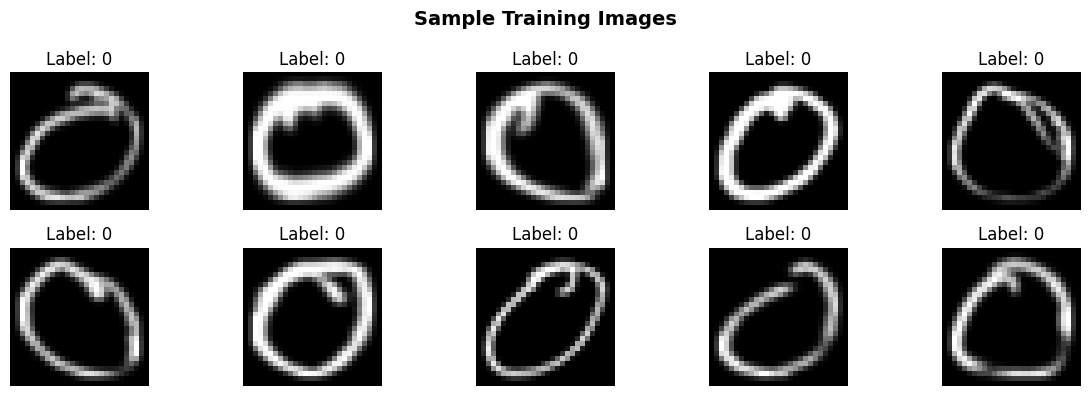

In [5]:
# Visualise 10 sample images from the training set
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture:
- **Flatten** layer: converts 28×28×1 → 784
- **Hidden layer 1**: 64 neurons, sigmoid
- **Hidden layer 2**: 128 neurons, sigmoid
- **Hidden layer 3**: 256 neurons, sigmoid
- **Output layer**: 10 neurons, softmax

In [6]:
# -------------------------------------------------------
# Task 2: Build the FCN Model (Sequential API)
# -------------------------------------------------------

input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

model = Sequential([
    Input(shape=input_shape),
    Flatten(),                              # 28x28x1 → 784
    Dense(64,  activation="sigmoid"),      # Hidden layer 1
    Dense(128, activation="sigmoid"),      # Hidden layer 2
    Dense(256, activation="sigmoid"),      # Hidden layer 3
    Dense(NUM_CLASSES, activation="softmax")  # Output layer
], name="Devnagari_FCN")

model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

In [7]:
# -------------------------------------------------------
# Task 3: Compile the Model
# -------------------------------------------------------

model.compile(
    optimizer="adam",                      # Adaptive Moment Estimation
    loss="categorical_crossentropy",       # Multi-class classification loss
    metrics=["accuracy"]                   # Monitor accuracy
)

print("Model compiled successfully.")
print(f"  Optimizer : adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully.
  Optimizer : adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

In [8]:
# -------------------------------------------------------
# Task 4: Train the Model
# -------------------------------------------------------

BATCH_SIZE     = 128
EPOCHS         = 20
VALIDATION_SPLIT = 0.2   # 20% of training data used for validation

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath="best_devnagari_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2882 - loss: 1.9138
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4807 - loss: 1.5479 - val_accuracy: 0.0000e+00 - val_loss: 7.8345
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8052 - loss: 0.5931
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8268 - loss: 0.4985 - val_accuracy: 0.0000e+00 - val_loss: 9.0136
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8844 - loss: 0.3315
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9009 - loss: 0.3014 - val_accuracy: 0.0000e+00 - val_loss: 9.7322
Epoch 4/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9323 - loss: 0.2253
Epoch 4: val_accuracy did not imp

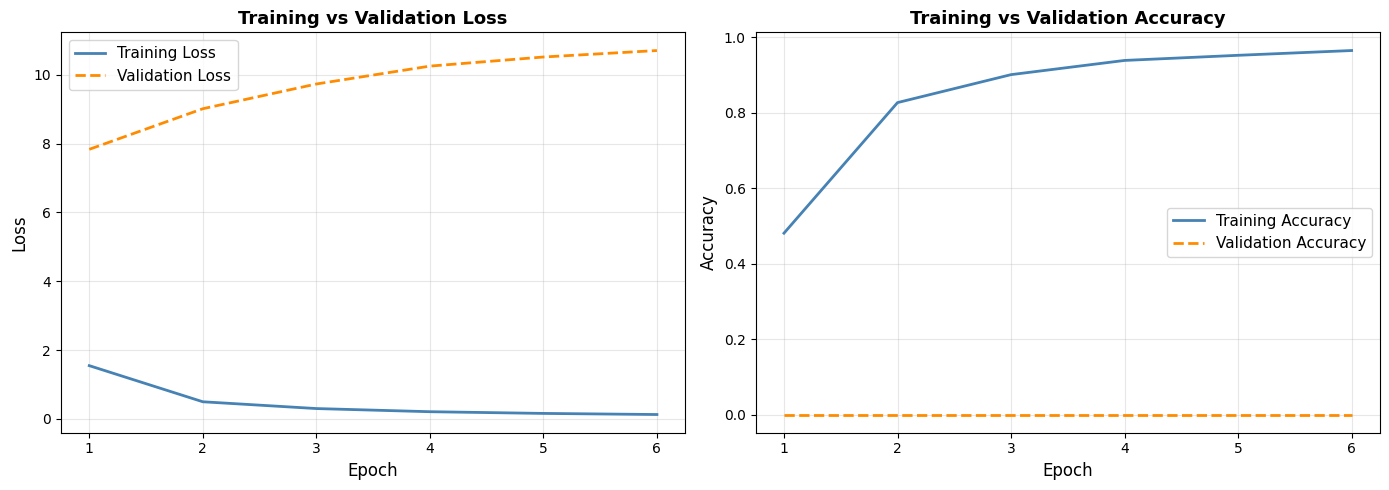

Training curves saved to training_curves.png


In [9]:
# Visualise training curves
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(epochs_ran, train_loss, label="Training Loss",   color="steelblue",  linewidth=2)
axes[0].plot(epochs_ran, val_loss,   label="Validation Loss", color="darkorange", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss",  fontsize=12)
axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_ran, train_acc, label="Training Accuracy",   color="steelblue",  linewidth=2)
axes[1].plot(epochs_ran, val_acc,   label="Validation Accuracy", color="darkorange", linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch",    fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Training vs Validation Accuracy", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved to training_curves.png")

---
## Task 5: Evaluate the Model

In [10]:
# -------------------------------------------------------
# Task 5: Evaluate the Model on the Test Set
# -------------------------------------------------------

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("\n" + "="*40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("="*40)

94/94 - 0s - 2ms/step - accuracy: 0.6187 - loss: 2.1814

  Test Loss     : 2.1814
  Test Accuracy : 0.6187  (61.87%)


---
## Task 6: Save and Load the Model

In [11]:
# -------------------------------------------------------
# Task 6a: Save the trained model
# -------------------------------------------------------

MODEL_PATH = "devnagari_fcn_model.h5"
model.save(MODEL_PATH)
print(f"Model saved to '{MODEL_PATH}'")

Model saved to 'devnagari_fcn_model.h5'


In [12]:
# -------------------------------------------------------
# Task 6b: Load the saved model and re-evaluate
# -------------------------------------------------------

loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from '{MODEL_PATH}'")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print("\n" + "="*40)
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)")
print("="*40)

Model loaded from 'devnagari_fcn_model.h5'
94/94 - 1s - 6ms/step - accuracy: 0.6187 - loss: 2.1814

  Loaded Model Test Loss     : 2.1814
  Loaded Model Test Accuracy : 0.6187  (61.87%)


---
## Task 7: Predictions

In [13]:
# -------------------------------------------------------
# Task 7: Make Predictions on Test Images
# -------------------------------------------------------

# Get predicted probabilities for all test images
predictions = loaded_model.predict(x_test, verbose=0)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# Show first 5 predictions
print("First 5 predictions:")
print("-" * 45)
print(f"{'Index':<8} {'True Label':<15} {'Predicted':<15} {'Correct?'}")
print("-" * 45)
for i in range(5):
    correct = "✓" if predicted_labels[i] == true_labels[i] else "✗"
    print(f"{i:<8} {true_labels[i]:<15} {predicted_labels[i]:<15} {correct}")

First 5 predictions:
---------------------------------------------
Index    True Label      Predicted       Correct?
---------------------------------------------
0        0               0               ✓
1        0               0               ✓
2        0               0               ✓
3        0               0               ✓
4        0               0               ✓


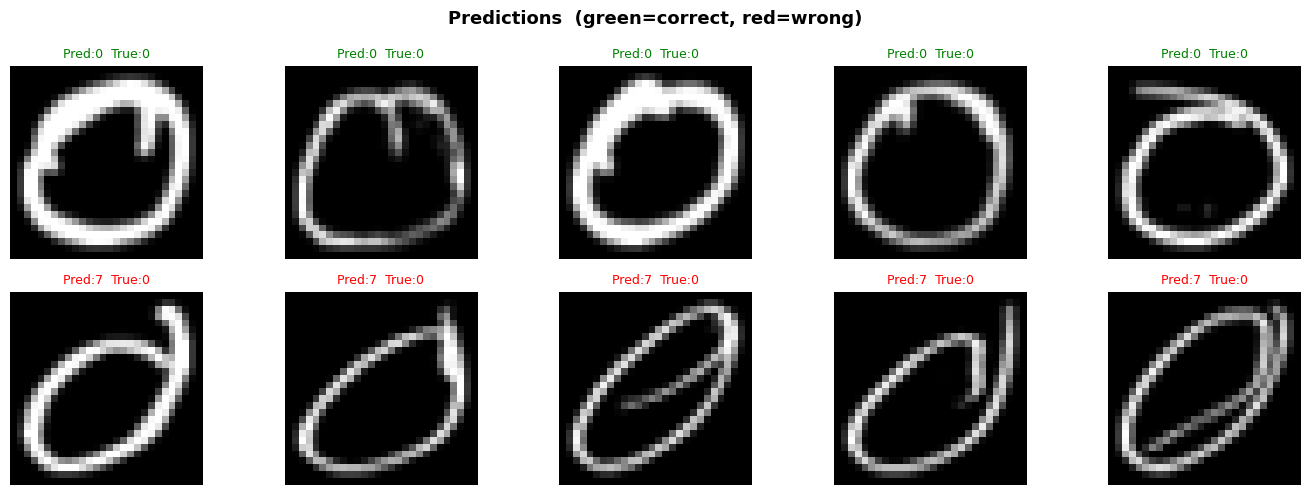

Prediction sample saved to predictions_sample.png


In [14]:
# Visualise 10 test predictions (5 correct, 5 wrong if available)
correct_idx   = np.where(predicted_labels == true_labels)[0][:5]
incorrect_idx = np.where(predicted_labels != true_labels)[0][:5]
sample_idx    = np.concatenate([correct_idx, incorrect_idx])

plt.figure(figsize=(14, 5))
for plot_i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    pred  = predicted_labels[idx]
    true  = true_labels[idx]
    color = "green" if pred == true else "red"
    plt.title(f"Pred:{pred}  True:{true}", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Predictions  (green=correct, red=wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("predictions_sample.png", dpi=150, bbox_inches="tight")
plt.show()
print("Prediction sample saved to predictions_sample.png")

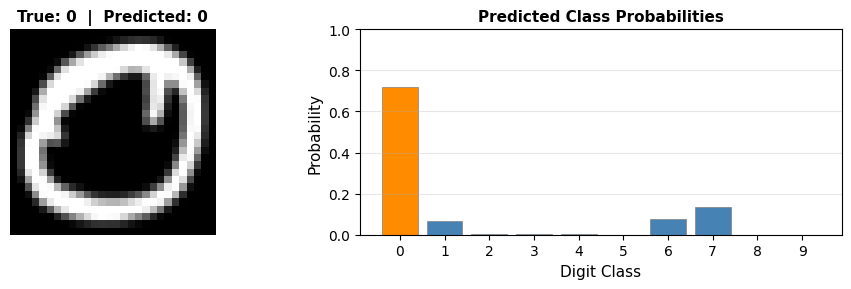


Probability breakdown for test image 0:
  Digit 0: 0.7173 <-- predicted
  Digit 1: 0.0673
  Digit 2: 0.0013
  Digit 3: 0.0014
  Digit 4: 0.0024
  Digit 5: 0.0007
  Digit 6: 0.0743
  Digit 7: 0.1350
  Digit 8: 0.0002
  Digit 9: 0.0001


In [15]:
# Confidence breakdown for a single test image
sample_idx_single = 0
sample_image      = x_test[sample_idx_single]
sample_probs      = predictions[sample_idx_single]

plt.figure(figsize=(10, 3))

# Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image.reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
plt.title(f"True: {true_labels[sample_idx_single]}  |  Predicted: {predicted_labels[sample_idx_single]}",
          fontsize=11, fontweight="bold")
plt.axis("off")

# Probability bar chart
plt.subplot(1, 2, 2)
colors = ["steelblue"] * NUM_CLASSES
colors[predicted_labels[sample_idx_single]] = "darkorange"
plt.bar(range(NUM_CLASSES), sample_probs, color=colors, edgecolor="gray", linewidth=0.5)
plt.xticks(range(NUM_CLASSES))
plt.xlabel("Digit Class", fontsize=11)
plt.ylabel("Probability", fontsize=11)
plt.title("Predicted Class Probabilities", fontsize=11, fontweight="bold")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nProbability breakdown for test image {sample_idx_single}:")
for digit, prob in enumerate(sample_probs):
    marker = " <-- predicted" if digit == predicted_labels[sample_idx_single] else ""
    print(f"  Digit {digit}: {prob:.4f}{marker}")

---
## Summary

| Step | Description | Status |
|------|-------------|--------|
| Task 1 | Data loading, normalisation, one-hot encoding | ✅ Done |
| Task 2 | FCN model: Flatten → 64 → 128 → 256 → 10 | ✅ Done |
| Task 3 | Compiled with Adam + categorical_crossentropy | ✅ Done |
| Task 4 | Trained for 20 epochs, batch=128, val_split=0.2 | ✅ Done |
| Task 5 | Evaluated on test set | ✅ Done |
| Task 6 | Saved as `.h5`, reloaded and re-evaluated | ✅ Done |
| Task 7 | Predictions visualised with confidence bars | ✅ Done |